In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result:str

In [5]:
def show_equation(state:QuadState) -> QuadState:
    equation = f"{state['a']}x^2 + ({state['b']})x + {state['c']}"

    return {'equation':equation}


def calc_discriminant(state:QuadState) -> QuadState:

    D = ((state['b']**2)  - (4 * state['a'] * state['c']))

    return {'discriminant':D}


In [10]:
import math

In [23]:
def real_roots(state:QuadState) -> QuadState:
 
    r1 = (-state['b'] + math.sqrt(state['discriminant']))/2*state['a']
    r2 = (-state['b'] - math.sqrt(state['discriminant']))/2*state['a']

    result = f"Two Distinct Roots : {r1} and {r2}"

    return {'result':result}

def equal_roots(state:QuadState) -> QuadState:
 
    root= (-state['b']) /2*state['a']
    

    result = f"Equals Roots : {root}"

    return {'result':result}
    

def img_roots(state:QuadState) -> QuadState:
 
    real_part = (-state['b'])/2*state['a']
    img_part = math.sqrt(abs(state['discriminant']))/2*state['a']

    root1 = f"{real_part} + {img_part}*i"
    root2 = f"{real_part} - {img_part}*i"

    result = f"Two Imaginary Complex Roots : {root1} and {root2}"

    return {'result':result}


In [39]:
# Routing Conditional function
def check_condition(state:QuadState):
    if state['discriminant'] > 0:
        return "positive"
    elif state['discriminant'] == 0:
        return "equal"
    else:
        return "negative"

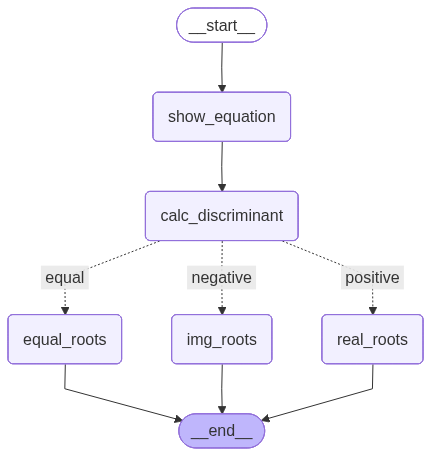

In [40]:
graph =  StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calc_discriminant',calc_discriminant)

#conditional nodes 
graph.add_node('real_roots',real_roots)
graph.add_node('equal_roots',equal_roots)
graph.add_node('img_roots',img_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calc_discriminant')
graph.add_conditional_edges('calc_discriminant',check_condition,{
    'positive':'real_roots',
    'equal':'equal_roots',
    'negative':'img_roots'
})
graph.add_edge('real_roots',END)
graph.add_edge('equal_roots',END)
graph.add_edge('img_roots',END)

workflow = graph.compile()
workflow

In [41]:
input = {
    'a':1,
    'b':-5,
    'c':6
}
workflow.invoke(input)

{'a': 1,
 'b': -5,
 'c': 6,
 'equation': '1x^2 + (-5)x + 6',
 'discriminant': 1,
 'result': 'Two Distinct Roots : 3.0 and 2.0'}

In [42]:
input = {
    'a':1,
    'b':-6,
    'c':9
}
workflow.invoke(input)

{'a': 1,
 'b': -6,
 'c': 9,
 'equation': '1x^2 + (-6)x + 9',
 'discriminant': 0,
 'result': 'Equals Roots : 3.0'}

In [43]:
input = {
    'a':1,
    'b':2,
    'c':5
}
workflow.invoke(input)

{'a': 1,
 'b': 2,
 'c': 5,
 'equation': '1x^2 + (2)x + 5',
 'discriminant': -16,
 'result': 'Two Imaginary Complex Roots : -1.0 + 2.0*i and -1.0 - 2.0*i'}